## Preamble

In [1]:
%run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [4]:
clean_spark()

CLEANING SPARK INSTANCE...


In [2]:
from datetime import datetime, timedelta, date
from dateutil import rrule
import re
import itertools

from collections import defaultdict
import publicsuffixlist as psl
import pandas as pd
import networkx as nx
from graphframes import GraphFrame

import pyspark.sql.types as pst
import pyspark.sql.functions as psf
from pyspark.sql.window import Window

import matplotlib.pyplot as plt

In [3]:
# Base prefix of fDNS warehouse data
FDNS_WAREHOUSE_BASE = "category=fdns/type=warehouse"
# Prefix format() template for (source, date)-partition fDNS warehouse data
FDNS_SOURCE_DT_PARTITION_FMT_TEMPLATE = os.path.join(FDNS_WAREHOUSE_BASE, "source={source}", "year={year}", "month={month:02d}", "day={day:02d}")

In [4]:
# when using r"" string (raw), no need to escape characters ("\\.")

# regex to extract sld.tld
all_suffixes = [s for s in psl.PublicSuffixList()._publicsuffix]  #if s and s.isascii()
tld_pattern = '|'.join(all_suffixes).replace("*.", "") #.replace(".", "\\.")

#domain_pattern_dot = fr"([^.]+)[.]({tld_pattern})[.]$"
domain_pattern = fr"([^.]+)[.]({tld_pattern}).?$"

#).withColumn("sld", psf.regexp_extract(psf.col("query_name"), domain_pattern, 1)
#).withColumn("tld", psf.regexp_extract(psf.col("query_name"), domain_pattern, 2)
#).withColumn("apex_domain", psf.concat_ws(".", psf.col("sld"), psf.col("tld"))  # psf.lit("") # last psf.lit("") is to add . to the end of the string

# without considering termination "."
#domain_pattern = f"([^.]+)\\.({tld_pattern})$"  # use [\\.] or \\.; doesn't matter...
#domain_pattern = fr"([^.]+)[.]({tld_pattern})$"

psl_obj = psl.PublicSuffixList()
broadcast_psl_obj = spark.sparkContext.broadcast(psl_obj)
@psf.pandas_udf("string")
def extract_apex_domain(query_name: pd.Series) -> pd.Series:
    return query_name.map(lambda x: broadcast_psl_obj.value.privatesuffix(x))

In [5]:
# claude sonet regex
rua_pattern = r'rua=([^;"]*)'  # old: r"rua=([^;]*)"  # older: "rua=[^@]+@([^;\s[\"]]+)"
ruf_pattern = r'ruf=([^;"]*)'  # old: r"ruf=([^;]*)"  # older: "ruf=[^@]+@([^;\s[\"]]+)"
user_domain_pattern = r'[^@,\s]*@'

In [5]:
def extract_rua_ruf_domains(df):
    df = df.filter(
        (psf.col("query_type") == "TXT")
        & (psf.col("query_name").startswith("_dmarc"))
    ).withColumn("rua_raw", psf.regexp_replace(psf.regexp_extract(psf.col("txt_text"), rua_pattern, 1), user_domain_pattern, "")
    ).withColumn("ruf_raw", psf.regexp_replace(psf.regexp_extract(psf.col("txt_text"), ruf_pattern, 1), user_domain_pattern, "")
    ).withColumn("rua_raw", psf.regexp_replace(psf.col("rua_raw"), 'mailto:| ', '') # trim mailto:
    ).withColumn("ruf_raw", psf.regexp_replace(psf.col("ruf_raw"), 'mailto:| ', '') # trim mailto:
    ).withColumn(# Split RUA by comma and trim
        "rua_addresses",
        psf.split(psf.col("rua_raw"), ",")
    ).withColumn(
        "ruf_addresses",
        psf.split(psf.col("ruf_raw"), ",")
    ).withColumn("rua_addresses", 
        psf.filter(psf.col("rua_addresses"), lambda x: psf.length(psf.trim(x)) > 0)
    ).withColumn("ruf_addresses", 
        psf.filter(psf.col("ruf_addresses"), lambda x: psf.length(psf.trim(x)) > 0)
    )
    return df

# deprecated function
def get_apex_domain(df, extract_column: str="query_name", pattern: str=domain_pattern, new_column_name: str="apex_domain"):
    # extract_column can be any column with a single domain name (not a list of domain names)
    df = df.withColumn(
        "sld", psf.regexp_extract(psf.col(extract_column), pattern, 1)
    ).withColumn("tld", psf.regexp_extract(psf.col(extract_column), pattern, 2)
    ).withColumn(new_column_name, 
            psf.when((psf.col("tld").isNull()) | (psf.length(psf.col("tld")) == 0), "")
               .otherwise(psf.concat_ws(".", psf.col("sld"), psf.col("tld"), psf.lit("")))  # the last psf.lit("") will add "." in the end of the domain.
    )

    return df


### Code examples

In [ ]:
# TEST CODE - EXTRACTED FROM EXAMPLE v0.1
SOURCES = ["com", "net", "org", "czds", "alexa", "majestic", "opencc", "radar", "tranco", "umbrella", "infra:ns", "infra:mx"]
START_DATE = datetime(2024, 1, 11)
END_DATE   = START_DATE

for i_dt in rrule.rrule(rrule.DAILY, dtstart=START_DATE, until=END_DATE):

    i_dt_sources_df = spark.read.option(
        "basePath", "s3a://openintel/{base}".format(base = FDNS_WAREHOUSE_BASE)
    ).format("parquet").load([
        "s3a://openintel/{prefix}".format(
            prefix = FDNS_SOURCE_DT_PARTITION_FMT_TEMPLATE.format(
                source = i_source, year = i_dt.year, month = i_dt.month, day = i_dt.day
            )
        )
        for i_source in SOURCES
    ])

In [ ]:
# TEST CODE - EXTRACTED FROM EXAMPLE v0.1
tranco_df = spark.read.option(
    "basePath", "s3a://openintel/category=fdns/type=warehouse/"
).parquet(*[ # n.b.: unpack
    "s3a://openintel/category=fdns/type=warehouse/source=tranco/year=2022/month=12/day=01/",
    "s3a://openintel/category=fdns/type=warehouse/source=tranco/year=2023/month=01/day=01"
]).filter(
    psf.col("ns_address").isNotNull()
).groupby(
    "year", "month", "day",
    "ns_address"
).agg(
    psf.countDistinct("query_name").alias("2ld_count") # n.b.: implied, as we only do NS queries on the @
).withColumn(
    "rank",
    psf.row_number().over(psw.Window().partitionBy("year", "month", "day").orderBy(psf.col("2ld_count").desc()))
)

tranco_df.filter(
    (psf.col("rank") <= 5)
).orderBy("year", "month", "day", "rank").show(50, truncate=False)

## Prepare input data for new measurements

In [46]:
# NO NEED TO USE infra:mx;
# a domain doesn't necessarily need to have mx record to be able to send reports
# if the domain sends dmarc report to itself, then it should have an mx record in its dns.
source = "infra:mx"
spark.read.option(
    "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source={source}"
).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source={source}/year=2025"
).select("month", "day").distinct().sort("month", "day", ascending=False
).show(truncate=False)

mx_date = datetime(2025, 7, 11)  # infra:mx has daily measurements; get latest; see previous cell output.
mx_df = spark.read.option(
    "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}"
).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source={source}/year={mx_date.year}/month={mx_date.month:02d}/day={mx_date.day:02d}")

mx_df.select("query_name", "query_type", "mx_address").show(5, truncate=False)

+-----+---+
|month|day|
+-----+---+
|7    |10 |
|7    |9  |
|7    |8  |
|7    |7  |
|7    |6  |
|7    |5  |
|7    |4  |
|7    |3  |
|7    |2  |
|7    |1  |
|6    |30 |
|6    |29 |
|6    |28 |
|6    |27 |
|6    |26 |
|6    |25 |
|6    |24 |
|6    |23 |
|6    |22 |
|6    |21 |
+-----+---+
only showing top 20 rows



In [ ]:
# extract domains from rua/ruf tags

# "You'd have to join back the infra:mx query_name AS mx_address on source=* & response_type=MX & mx_address=mx_address and then get source=*'s _dmarc.query_name"

sources = ["com", "net", "org", "czds", "alexa", "majestic", "opencc", "radar", "tranco", "umbrella"]
start_date = datetime(2025, 7, 11)

# extract rua/ruf tags
for source in sources:
    # load dataset
    try:
        source_df = spark.read.option(
            "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}"
        ).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}")
    except Exception as e:
        print(f"Path/data for source {source} not found. {e}")
        continue

    if False:
        # remove the mx from the join..
        mx_selected_df = mx_df.select(psf.col("query_name").alias("query_name_mx"))
    
        # join the loaded dataset with the mail server dataset on mx_address names
        # extract rua/ruf addresses from only those with _dmarc queries on TXT record
        mx_on_source_df = source_df.select("query_name", "query_type", "mx_address"
        ).filter(
            (psf.col("query_type") == "MX")
            & (psf.col("mx_address").isNotNull())
        ).join(
            mx_selected_df,
            source_df.mx_address == mx_selected_df.query_name_mx,
            how="inner"
        ).select(psf.col("query_name"))
    
        mx_on_source_dmarc_df = mx_on_source_df.select(psf.concat(psf.lit("_dmarc."), psf.col("query_name")).alias("query_name"))
        
        joined_df = source_df.select("query_name", "query_type", "txt_text").filter(
            (psf.col("query_name").startswith("_dmarc."))
            & (psf.col("query_type") == "TXT")
        ).join(
            mx_on_source_dmarc_df,
            on=["query_name"],
            how="inner"
        ).select("query_name", "query_type", "txt_text")
        df = joined_df

    df = source_df.select("query_name", "query_type", "txt_text").filter(
            (psf.col("query_name").startswith("_dmarc."))
            & (psf.col("query_type") == "TXT")
    ).withColumn(
        "query_name", psf.regexp_replace("query_name", r"^_dmarc.", "")
    )

    # rua/ruf tags should be FQDN, not just apex domain, otherwise subsequente measurements won't work.
    rua_ruf_df = extract_rua_ruf_domains(df).filter((psf.length(psf.col("rua_raw")) > 0) | (psf.length(psf.col("ruf_raw")) > 0)).drop(*("rua_raw", "ruf_raw", "query_type", "txt_text")
    ).groupBy("query_name").agg(
        psf.collect_set("rua_addresses").alias("rua_addresses_list"),
        psf.collect_set("ruf_addresses").alias("ruf_addresses_list"),
    ).select("query_name", psf.explode("rua_addresses_list").alias("col1"), psf.explode("ruf_addresses_list").alias("col2")
    ).select("query_name", psf.explode("col1").alias("rua_address"), psf.explode("col2").alias("ruf_address")
    ).withColumn("source", psf.lit(source))

    rua_df = rua_ruf_df.select("source", "query_name", psf.col("rua_address").alias("rua_ruf_address"))
    ruf_df = rua_ruf_df.select("source", "query_name", psf.col("ruf_address").alias("rua_ruf_address"))

    output = f"s3a://luvizottocesarg-tmp/oi-warehouse/rua-ruf-address/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"
    rua_df.union(ruf_df).distinct().write.parquet(output)


In [49]:
sources = ["com", "net", "org", "czds", "alexa", "majestic", "opencc", "radar", "tranco", "umbrella"]
for source in sources:
    try:
        print(
            source, 
            spark.read.option(
                    "basePath", "s3a://luvizottocesarg-tmp/oi-warehouse/rua-ruf-address"
            ).parquet(f"s3a://luvizottocesarg-tmp/oi-warehouse/rua-ruf-address/source={source}/").count()
        )
    except:
        continue

com 9300405
net 554674
org 667449
czds 1265975


In [43]:
spark.read.option("basePath", "s3a://luvizottocesarg-tmp/oi-warehouse/rua-ruf-address"
            ).parquet(f"s3a://luvizottocesarg-tmp/oi-warehouse/rua-ruf-address/source=com/"
            ).withColumn("query_name",
                         psf.regexp_replace("query_name", r"^_dmarc.", "")
            ).show(truncate=False)

+------+-------------------------------+------------------+----+-----+---+
|source|query_name                     |rua_ruf_address   |year|month|day|
+------+-------------------------------+------------------+----+-----+---+
|com   |007entertainment.com.          |onsecureserver.net|2025|7    |11 |
|com   |04186222.com.                  |onsecureserver.net|2025|7    |11 |
|com   |09079454.com.                  |onsecureserver.net|2025|7    |11 |
|com   |0xmacro.com.                   |0xmacro.com       |2025|7    |11 |
|com   |118inns.com.                   |qiye.163.com      |2025|7    |11 |
|com   |1232book.com.                  |secured-mall.com  |2025|7    |11 |
|com   |175173.com.                    |qq.com            |2025|7    |11 |
|com   |1masterhub.com.                |1masterhub.com    |2025|7    |11 |
|com   |1solution.com.                 |onsecureserver.net|2025|7    |11 |
|com   |1tambahkali.com.               |microsoft.com     |2025|7    |11 |
|com   |1tyco.com.       

## Prepare the dataset

Store a dataset such as:  

source,query_name,apex_domain,country,timestamp,mx_address,mx_apex_domain,mx_country,rua_domain,rua_apex_domain,ruf_domain,ruf_apex_domain,has_passed_edv,is_override_allowed,override_rua_domain,override_ruf_domain  

In [17]:
# country is taken from A/AAAA records. 
d = datetime(2025, 7, 11)
spark.read.option(
    "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}"
).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source=czds/year={d.year}/month={d.month:02d}/day={d.day:02d}"
).filter(psf.col("country").isNotNull()).groupBy("query_type").count().show()

+----------+--------+
|query_type|   count|
+----------+--------+
|     AFSDB|     693|
|         A|96480432|
|      AAAA|33814238|
+----------+--------+



In [47]:
d = datetime(2025, 7, 11)
spark.read.option(
    "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}"
).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source=infra:mx/year={d.year}/month={d.month:02d}/day={d.day:02d}"
).filter(psf.col("country").isNotNull()).groupBy("query_type").count().show()

+----------+--------+
|query_type|   count|
+----------+--------+
|         A|99615346|
|      AAAA|51987543|
+----------+--------+



## Loading the dataset

In [47]:
source = "tranco"
start_date = datetime(2025, 7, 11)  # tranco has daily measurements

tranco_df = spark.read.option(
    "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}"
).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}")

In [25]:
tranco_df.printSchema()

root
 |-- query_type: string (nullable = true)
 |-- query_name: string (nullable = true)
 |-- response_type: string (nullable = true)
 |-- response_name: string (nullable = true)
 |-- response_ttl: integer (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- rtt: double (nullable = true)
 |-- worker_id: integer (nullable = true)
 |-- status_code: integer (nullable = true)
 |-- ad_flag: integer (nullable = true)
 |-- section: string (nullable = true)
 |-- ip4_address: string (nullable = true)
 |-- ip6_address: string (nullable = true)
 |-- country: string (nullable = true)
 |-- as: string (nullable = true)
 |-- as_full: string (nullable = true)
 |-- ip_prefix: string (nullable = true)
 |-- cname_name: string (nullable = true)
 |-- dname_name: string (nullable = true)
 |-- mx_address: string (nullable = true)
 |-- mx_preference: integer (nullable = true)
 |-- ns_address: string (nullable = true)
 |-- txt_text: string (nullable = true)
 |-- ds_key_tag: integer (nullable = true)
 

In [ ]:
# cc of domain: response_type A for query_name
# cc of mx: response_type A for mx_address in infra:mx
# mx of domain = response_type MX for query_name
# for rua/ruf extract via regex -- psf.regex_extract

## Data overview

In [8]:
# be careful with what to consider "all domains";
# there are more A queries than MX queries...
# queries might also differ (e.g. _dmarc.fqdn on txt type or fqdn on mx type)
print(
    tranco_df.filter(
        psf.col("query_type") == "A"
    ).select("query_name").distinct().count(),

    tranco_df.filter(
        psf.col("query_type") == "MX"
    ).select("query_name").distinct().count(),
)

1756442 688056


All domains that exists

In [105]:
all_domains_cnt = tranco_df.withColumn("apex_domain", extract_apex_domain("query_name")).select("apex_domain").distinct().count()

print(all_domains_cnt)
# tranco (2024, 3, 14): 943465
# tranco (2025, 7, 11): 1005207

1005207


In [80]:
try:
    dmarc_domains_df.unpersist()
except:
    pass

dmarc_domains_df = get_apex_domain(
    tranco_df.filter(
        (psf.col("query_type") == "TXT")
        & (psf.col("query_name").startswith("_dmarc"))
        & (psf.col("txt_text").contains("v=DMARC1"))
    )
).select("apex_domain").distinct()

dmarc_domains_df.persist()

DataFrame[apex_domain: string]

Domains with DMARC (v=DMARC1)

In [81]:
dmarc_domains_cnt = dmarc_domains_df.count()

In [22]:
print("w/ dmarc:", dmarc_domains_cnt, "\nproportion of domains w/ DMARC w.r.t all domains:", round(dmarc_domains_cnt/all_domains_cnt*100, 1), "%")

w/ dmarc: 426005 
proportion of domains w/ DMARC w.r.t all domains: 42.4 %


Domains that have an MX server

In [15]:
names_with_mx_df = get_apex_domain(
    tranco_df.filter(
        (psf.col("query_type") == "MX")
        & (psf.col("mx_address").isNotNull())
    )
).select("apex_domain").distinct()

In [23]:
names_w_mx_cnt = names_with_mx_df.count()
print(names_w_mx_cnt)

677749


In [24]:
print(round(names_w_mx_cnt/all_domains_cnt*100,1))

67.4


proportion of domains that have MX and have DMARC enabled (v=DMARC1) and w/ MX

In [17]:
dmarc_domains_w_mx_df = dmarc_domains_df.join(
    names_with_mx_df, on=["apex_domain"], how="inner"
).select("apex_domain").distinct()

dmarc_domains_w_mx_cnt = dmarc_domains_w_mx_df.count()

In [18]:
print("w/ dmarc & mx:", dmarc_domains_w_mx_cnt, "\nproportion of domains w/ DMARC and MX w.r.t domains w/ MX only:", round(dmarc_domains_w_mx_cnt/names_w_mx_cnt*100, 1), "%")

w/ dmarc & mx: 402763 
proportion of domains w/ DMARC and MX w.r.t domains w/ MX only: 59.4 %


without MX but with DMARC

In [25]:
no_mx_w_dmarc = dmarc_domains_cnt-dmarc_domains_w_mx_cnt
print(no_mx_w_dmarc, "proportion w.r.t. all domains:", round(no_mx_w_dmarc/all_domains_cnt*100,1))

23242 proportion w.r.t. all domains: 2.3


What is the proportion of domains using rua/ruf tags?

In [85]:
dmarc_tag_df = extract_rua_ruf_domains(
        tranco_df.filter(
            (psf.col("query_type") == "TXT")
            & (psf.col("query_name").startswith("_dmarc"))
            & (psf.col("txt_text").contains("v=DMARC1"))
        ).withColumn("apex_domain", extract_apex_domain("query_name")).select("query_name", "apex_domain", "query_type", "txt_text")
).filter((psf.length(psf.col("rua_raw")) > 0) | (psf.length(psf.col("ruf_raw")) > 0)
).drop(*("rua_raw", "ruf_raw", "query_type", "txt_text")
)

dmarc_report_address_df = get_apex_domain(  # for ruf
    get_apex_domain(  # for rua
    dmarc_tag_df.select("apex_domain", "ruf_addresses", psf.explode(psf.col("rua_addresses")).alias("rua_address")),
    extract_column="rua_address", new_column_name="rua_apex_domain"
).select("apex_domain", "rua_apex_domain", psf.explode(psf.col("ruf_addresses")).alias("ruf_address")), 
    extract_column="ruf_address", new_column_name="ruf_apex_domain"
).show(truncate=False)

# test: oslobodjenje.ba.
#).groupBy("apex_domain").agg(
#    psf.collect_set("rua_addresses").alias("rua_addresses_list"),
#    psf.collect_set("ruf_addresses").alias("ruf_addresses_list"),
#).withColumn(
#    "has_rua", psf.when((psf.size(psf.col("rua_addresses_list")) == 1) & (psf.size(psf.col("rua_addresses_list").getItem(0)) == 0), False).otherwise(True)
#).withColumn(
#    "has_ruf", psf.when((psf.size(psf.col("ruf_addresses_list")) == 1) & (psf.size(psf.col("ruf_addresses_list").getItem(0)) == 0), False).otherwise(True)
#)

#rua_nr = dmarc_tag_df.filter(psf.col("has_rua") == True).select("apex_domain").distinct().count()
#ruf_nr = dmarc_tag_df.filter(psf.col("has_ruf") == True).select("apex_domain").distinct().count()
if False:
    print(
        "rua:", rua_nr, "out of", dmarc_domains_cnt,
        round(rua_nr / dmarc_domains_cnt * 100, 1), "%",
    
        "\nruf:", ruf_nr, "out of", dmarc_domains_cnt,
        round(ruf_nr / dmarc_domains_cnt * 100, 1), "%"
    )

+----------------------+-----------------+---------------------------+-------------+---+-----------------+
|apex_domain           |rua_apex_domain  |ruf_address                |sld          |tld|ruf_apex_domain  |
+----------------------+-----------------+---------------------------+-------------+---+-----------------+
|oslobodjenje.ba.      |oslobodjenje.ba. |oslobodjenje.ba            |oslobodjenje |ba |oslobodjenje.ba. |
|oslobodjenje.ba.      |oslobodjenje.ba. |forensics.dmarc-report.com |dmarc-report |co |dmarc-report.co. |
|oslobodjenje.ba.      |dmarc-report.co. |oslobodjenje.ba            |oslobodjenje |ba |oslobodjenje.ba. |
|oslobodjenje.ba.      |dmarc-report.co. |forensics.dmarc-report.com |dmarc-report |co |dmarc-report.co. |
|name.ba.              |name.ba.         |name.ba                    |name         |ba |name.ba.         |
|telemach.ba.          |telemach.ba.     |telemach.ba                |telemach     |ba |telemach.ba.     |
|mtel.ba.              |mtel.ba.     

spoofed paper (p.13): rua: 41.99%, ruf: 20.57%

Comparison with related work:  
[Spoofed] - czds, passive DNS SIE EU, CT logs, Tranco 5M; Table 2: 
NO MX, DMARC with rua/ruf = 1,270,352  
NO MX, DMARC without rua/ruf = 909,347  
MX, DMARC with rua/ruf = 5,435,578  
MX, DMARC without rua/ruf = 8,354,295  

[Ashiq]  
TLD,  Domains with MX Records,DMARC,DMARC %, Report,Report %, Report from Ext.,Report from Ext. %  
.com, 75.6M,                  5.0M, 6.6%,    2.4M, 49.4%,     1.7M, 68.8%  
.net, 6.5M,                   453K, 6.9%,    245K, 54.1%,     172K, 70.2%  
.org, 5.8M,                   390K, 6.7%,    213K, 54.5%,     152K, 71.4%  
.se,  848K,                   81K,  9.6%,    30K,  37.4%,     24K,  80.1%  

In [ ]:
error_ruas_rufs = get_apex_domain(  # for rufs
    get_apex_domain(  # for ruas
            dmarc_tag_df.select("apex_domain", "ruf_addresses_list", psf.explode(psf.col("rua_addresses_list")).alias("col1")
                    ).select("apex_domain", "ruf_addresses_list", psf.explode("col1").alias("rua_address")).distinct(), 
            extract_column="rua_address", new_column_name="rua_apex_domain"
        ).select("apex_domain", "rua_apex_domain", psf.explode(psf.col("ruf_addresses_list")).alias("col1")
                    ).select("apex_domain", "rua_apex_domain", psf.explode("col1").alias("ruf_address")).distinct(),
            extract_column="ruf_address", new_column_name="ruf_apex_domain"
    ).withColumn(  # here I have apex_domain, rua_apex_domain, ruf_apex_doain that I can analyze
        "rua_err", psf.when((psf.col("rua_apex_domain").isNull()) | (psf.length(psf.col("rua_apex_domain"))==0), 1).otherwise(0)
    ).withColumn(
        "ruf_err", psf.when((psf.col("ruf_apex_domain").isNull()) | (psf.length(psf.col("ruf_apex_domain"))==0), 1).otherwise(0)
    ).groupBy("apex_domain").agg(
        psf.collect_set("rua_apex_domain").alias("rua_apex_domain_list"),
        psf.collect_set("rua_err").alias("rua_err_list"),
        psf.collect_set("ruf_err").alias("ruf_err_list"),
    ).withColumn(
        "has_rua_err", psf.when(psf.array_contains(psf.col("rua_err_list"), 1), True).otherwise(False)
    ).withColumn(
        "has_ruf_err", psf.when(psf.array_contains(psf.col("ruf_err_list"), 1), True).otherwise(False)
    ).groupBy("has_rua_err", "has_ruf_err").count(
    ).withColumn(
        "percent", psf.lit(100) * psf.col('count') / psf.sum('count').over(Window.partitionBy())
    )

error_ruas_rufs.show(truncate=False)

## RQ1 - To what extent are domain owners dependent on third-parties organizations for processing DMARC reports?

Get DMARC measurements from domains that exist and that have an MX server

In [19]:
# unpersist what is going to be persisted in this cell in case we run the cell 2x
try:
    dmarc_w_mx_df.unpersist()
except:
    pass

# limit mx_names_df to speed up execution
# a domain that may have dmarc meas and mx server may appear without having them because of this cut;
#limit = 0  # all; no limit
limit = 10000

# domains may have 2 TXT answers for _dmarc queries. E.g.:
# dig -t txt +short _dmarc.vaktija.ba
#"v=DMARC1; p=reject; sp=reject; adkim=s; aspf=s;"
#"v=DMARC1; p=none; rua=mailto:postmaster@vaktija.ba"
apex_df = get_apex_domain(tranco_df.filter(
    (psf.col("query_type") == "MX")
    | (psf.col("query_type") == "TXT")
    | (psf.col("query_type") == "A")
)).select("query_name", "query_type", "apex_domain", "ip4_address", "mx_address", "year", "month", "day", "country", "txt_text")

# apply limit of apex domain to speed up analysis. Comment this code
if limit == 0:
    df = apex_df
else:
    lim_distinct_domains = apex_df.select("apex_domain").dropDuplicates().limit(limit)
    lim_apex_df = apex_df.join(lim_distinct_domains, on="apex_domain", how="inner")
    df = lim_apex_df

window = Window.partitionBy("apex_domain")

flags_df = df.withColumn(
    "has_dmarc", psf.max(psf.when(psf.col("query_name").startswith("_dmarc."), 1).otherwise(0)).over(window)
).withColumn(
    "has_mx", psf.max(psf.when((psf.col("query_type") == "MX") & psf.col("mx_address").isNotNull(), 1).otherwise(0)).over(window)
).withColumn(
    "has_ip", psf.max(psf.when(psf.col("ip4_address").isNotNull(), 1).otherwise(0)).over(window)
)

# Filter for domains that have both DMARC and MX records
dmarc_w_mx_df = flags_df.filter(
    (psf.col("has_dmarc") == 1) &
    (psf.col("has_mx") == 1)
).drop("has_dmarc", "has_mx", "has_ip")

#if limit == 0:
dmarc_w_mx_df.persist()

dmarc_w_mx_df.show(truncate=False)

+----------------+-----------------------+----------+---------------+------------------------+----+-----+---+-------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|apex_domain     |query_name             |query_type|ip4_address    |mx_address              |year|month|day|country|txt_text                                                                                                                                                                                                                                                     |
+----------------+-----------------------+----------+---------------+------------------------+----+-----+---+-------+-------------------------------------------------------------------------------------------------------------------------------------------

In [11]:
# limit is non deterministic
dmarc_w_mx_df.count()

42100

In [12]:
# I did some filtering (domains that has_dmarc and has_mx), that's why is not "lim" anymore
dmarc_w_mx_df.select("apex_domain").distinct().count()

3634

In [14]:
lim_distinct_domains.count()

10000

Required to speed up analysis...

In [7]:
start_date = datetime(2025, 7, 11)
dmarc_mx_path = f"s3a://luvizottocesarg-tmp/oi-warehouse/testing/source=tranco/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"

In [21]:
dmarc_w_mx_df.write.parquet(dmarc_mx_path)

In [10]:
dmarc_w_mx_df = spark.read.parquet(dmarc_mx_path)

In [11]:
# for limit to be deterministic, it's better to use sample(n, seed=1234).
dmarc_w_mx_df.count()
# limit + tranco of 2024,3,14:
# 43040
# limit + tranco of 2025,7,11:
# 62946

62946

In [38]:
dmarc_w_mx_df.groupBy("query_type").count().show()
# limit + tranco of 2024,3,14:
#+----------+-----+
#|query_type|count|
#+----------+-----+
#|        MX| 8910|
#|       TXT|19809|
#|         A|14321|
#+----------+-----+
# limit + tranco of 2025,7,11:
#+----------+-----+
#|query_type|count|
#+----------+-----+
#|        MX|11007|
#|       TXT|26477|
#|         A|19230|
#+----------+-----+

+----------+-----+
|query_type|count|
+----------+-----+
|        MX|11007|
|       TXT|26477|
|         A|19230|
+----------+-----+



#### How many of these are organizations, private users, and others?

In [12]:
apx_ruas_rufs_df = extract_rua_ruf_domains(dmarc_w_mx_df).groupBy("apex_domain"  # one domain may have multiple TXT records
).agg(
    psf.collect_set("rua_addresses").alias("rua_addresses_list"),   # list(list)
    psf.collect_set("ruf_addresses").alias("ruf_addresses_list")  # list(list))
)

In [77]:
# CAREFUL WHEN USING THE FULL DATASET. IT MAY NEED TO SAVE TO OBJSTORE AND THEN LOAD IT AGAIN...
rua_pdf = apx_ruas_rufs_df.select(psf.explode("rua_addresses_list").alias("rua_addresses")).select(psf.explode("rua_addresses").alias("rua_domain")).toPandas()

ruf_pdf = apx_ruas_rufs_df.select(psf.explode("ruf_addresses_list").alias("ruf_addresses")).select(psf.explode("ruf_addresses").alias("ruf_domain")).toPandas()

rua_ruf_pdf = apx_ruas_rufs_df.select(psf.explode("rua_addresses_list").alias("rua_addresses")).select(psf.explode("rua_addresses").alias("rua_ruf_domain")
).union(apx_ruas_rufs_df.select(psf.explode("ruf_addresses_list").alias("ruf_addresses")).select(psf.explode("ruf_addresses").alias("rua_ruf_domain"))
).toPandas()

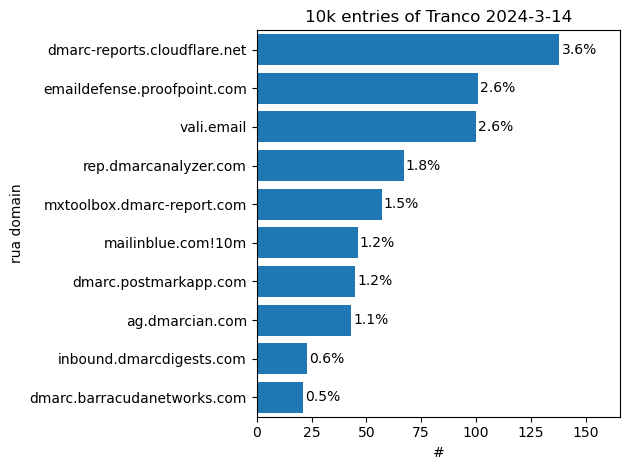

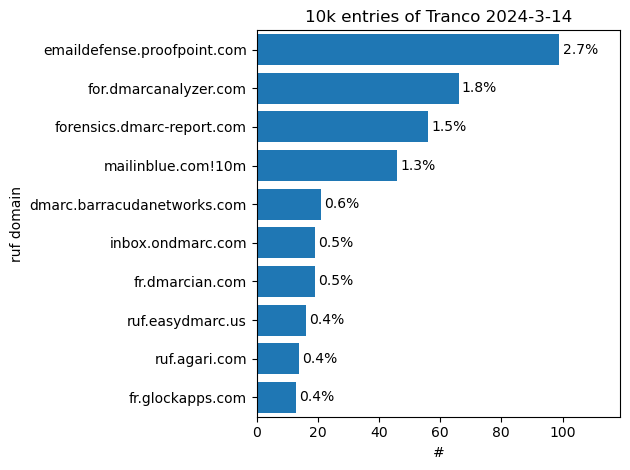

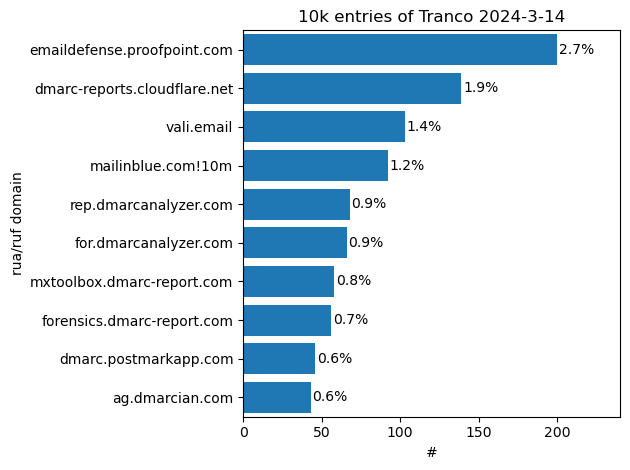

,rua_ruf_domain,count,percent
485,emaildefense.proofpoint.com,200,2.676660
399,dmarc-reports.cloudflare.net,139,1.860278
1537,vali.email,103,1.378480
921,mailinblue.com!10m,92,1.231263
1232,rep.dmarcanalyzer.com,68,0.910064
569,for.dmarcanalyzer.com,66,0.883298
1020,mxtoolbox.dmarc-report.com,58,0.776231
571,forensics.dmarc-report.com,56,0.749465
418,dmarc.postmarkapp.com,46,0.615632
61,ag.dmarcian.com,43,0.575482


In [113]:
def _plot_dmarc_ruaruf_tag(top_n, domain_tag, ylabel):
    plt.figure()

    bars = plt.barh(top_n[domain_tag], top_n["count"])
    for i, (count, percent) in enumerate(zip(top_n["count"], top_n["percent"])):
        plt.text(count + 1, i, f'{percent:.1f}%', va='center', ha='left')

    plt.xlabel("#")
    plt.ylabel(ylabel)
    plt.title(f"10k entries of Tranco {start_date.year}-{start_date.month}-{start_date.day}")
    plt.xlim(0, top_n["count"].max() * 1.2)
    num_categories = len(top_n)
    plt.ylim(-.5, num_categories - .5)  # Minimal padding
    plt.gca().invert_yaxis()  # To show highest values at top
    plt.tight_layout()
    plt.savefig(f"figures/{domain_tag}_proportion.pdf", bbox_inches='tight')
    plt.show()

agg_rua_pdf = rua_pdf.groupby("rua_domain").size().reset_index(name="count").sort_values(by="count", ascending=False)
agg_rua_pdf["percent"] = 100 * agg_rua_pdf["count"] / agg_rua_pdf["count"].sum()
#agg_rua_pdf["rua_domain"] = agg_rua_pdf['rua_domain'].replace('', 'No rua tag')
agg_rua_pdf = agg_rua_pdf[agg_rua_pdf["rua_domain"] != ""] # filter out no rua tag rows
ylabel = "rua domain"
top_n = agg_rua_pdf.head(10)
_plot_dmarc_ruaruf_tag(top_n, "rua_domain", "rua domain")

agg_ruf_pdf = ruf_pdf.groupby("ruf_domain").size().reset_index(name="count").sort_values(by="count", ascending=False)
agg_ruf_pdf["percent"] = 100 * agg_ruf_pdf["count"] / agg_ruf_pdf["count"].sum()
#agg_ruf_pdf["ruf_domain"] = agg_ruf_pdf['ruf_domain'].replace('', 'No ruf tag')
agg_ruf_pdf = agg_ruf_pdf[agg_ruf_pdf["ruf_domain"] != ""]
ylabel = "ruf domain"
top_n = agg_ruf_pdf.head(10)
_plot_dmarc_ruaruf_tag(top_n, "ruf_domain", "ruf domain")

# altogether
agg_rua_ruf_pdf = rua_ruf_pdf.groupby("rua_ruf_domain").size().reset_index(name="count").sort_values(by="count", ascending=False)
agg_rua_ruf_pdf["percent"] = 100 * agg_rua_ruf_pdf["count"] / agg_rua_ruf_pdf["count"].sum()
#agg_ruf_pdf["ruf_domain"] = agg_ruf_pdf['ruf_domain'].replace('', 'No ruf tag')
agg_rua_ruf_pdf = agg_rua_ruf_pdf[agg_rua_ruf_pdf["rua_ruf_domain"] != ""]
ylabel = "rua/ruf domain"
top_n = agg_rua_ruf_pdf.head(10)
_plot_dmarc_ruaruf_tag(top_n, "rua_ruf_domain", "rua/ruf domain")
display(top_n)

top 10 are all organisations (no individuals/admins)   
dmarc-report.com - doesn't exist  
postmarkapp.com - email delivery company  
cloudflare - cdn with email sec service  
the rest are email security companies.  

related work: proofpoint.com, reportdmarc.nl, mailingblue.com, agari.com, dmarcanalyzer.com, 163.com, dmarcian.com, dmarc-report.com, amazon.com, cloudflare.net, vali.email, gmail.com, secureserver.net, cisco.com, dmarcadvisor.com, domeneshop.no, postmarkapp.com, ondmarc.com, barracudanetworks.com, microhost.pl  

#### What relations can we find between target mail exchangers in ruf/rua and the domain owners?

How many times multiple mailto: is present in rua/ruf tags?

In [24]:
apx_ruas_rufs_df.select(psf.explode("rua_addresses_list").alias("rua_addresses")).withColumn(
    "nr_ruas", psf.size("rua_addresses")
).groupBy("nr_ruas").count().show()

apx_ruas_rufs_df.select(psf.explode("ruf_addresses_list").alias("ruf_addresses")).withColumn(
    "nr_rufs", psf.size("ruf_addresses")
).groupBy("nr_rufs").count().show()

+-------+-----+
|nr_ruas|count|
+-------+-----+
|      1| 4442|
|      3|   32|
|      5|    1|
|      4|    3|
|      2|  311|
+-------+-----+

+-------+-----+
|nr_rufs|count|
+-------+-----+
|      1| 4646|
|      3|   13|
|      2|  104|
+-------+-----+



How many corner cases among all domains?

In [15]:
#bgazrt.hu BGAZRT.HU
#conferencenext.com mailinblue.com!10m
#crediautos.cl crediautos
#fruugo.com.tr
#mydwoje.pl dplads.com>
#pravslovo.ru pravslovo.ruadkim=r
#cambridgeone.org cambridge.o
#cfc.org.br tuxon.com.br._report._dmarc
#drogaraia.com.br DMARC.EVEREST.EMAIL
#gatefy.com mailto
#xiantao.gov.cn qiye.163.com.
#xtreme.bet xtreme.bet\
#anglesey.gov.uk ruf.aga
#astroved.com pct=100
case = 'agricolors.fr'
dmarc_w_mx_df.filter(
    (psf.col("query_type") == "TXT")
    & (psf.col("query_name").startswith("_dmarc."))
    & (psf.col("query_name").contains(case))
).select("txt_text").show(truncate=False)

apx_ruas_rufs_df.filter(
    psf.col("apex_domain").contains(case)
).show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------+
|txt_text                                                                                                                         |
+---------------------------------------------------------------------------------------------------------------------------------+
|"v=DMARC1; p=none; sp=none; rua=mailto:dmarc@mailinblue.com!10m; ruf=mailto:dmarc@mailinblue.com!10m; rf=afrf; pct=100; ri=86400"|
|NULL                                                                                                                             |
+---------------------------------------------------------------------------------------------------------------------------------+

+--------------+----------------------+----------------------+
|apex_domain   |rua_addresses_list    |ruf_addresses_list    |
+--------------+----------------------+----------------------+
|agricolors.fr.|[[

In [ ]:
# corner cases - with limit and tranco 2024:
# 1 - email domain has a typo
# a - missing TLD in one of the mailto
# apex_domain="crediautos.cl" -> ruf=mailto:dmarc_ruf@crediautos,mailto:dmarc_ruf@emaildefense.proofpoint.com;
# b - characters (quotes) added to the rua/ruf domain name
# apex_domain="cambridgeone.org" -> "v=DMARC1; p=quarantine; rua=mailto:644b4767adf94d2a9f33fbe1b9072971@dmarc-reports.cloudflare.net,mailto:047acbdc29a7625@rep.dmarcanalyzer.com,mailto:dmarc-admin@cambridge.org; ruf=mailto:047acbdc29a7625@for.dmarcanalyzer.com,mailto:dmarc-admin@cambridge.o""rg; fo=1;"
# apex_domain="xtreme.bet" -> "\"v=DMARC1; p=reject; sp=reject; ruf=mailto:authfail@xtreme.bet; rua=mailto:aggrep@xtreme.bet\""
# apex_domain="anglesey.gov.uk" -> ruf=mailto:isle-of-anglesey-council@ruf.aga""ri-eu.com,mailto:dmarc-rua@dmarc.service.gov.uk
# c - misinterpretation of the standard
# apex_domain="cfc.org.br" -> "v=DMARC1;p=none;pct=100;rua=mailto:postmaster@mensageiro.tuxon.com.br,mailto:mensageiro@tuxon.com.br._report._dmarc"
# d - typo on mailto:
# apex_domain="gatefy.com" -> ruf=mailto:ed75d258-6313-11ea-bc55-0242ac130003@antifraud.gatefy.com,mailto:support@gatefy.com,mailto"":6a13379d44@ruf.easydmarc.com;"

# 2 - domain name is malformed according to RFC 5321 because of the syntax of domain name is not valid according to RFC 1035 sec. 2.3.1
# apex_domain="" -> mailinblue.com!10m
# 3 - malformed txt record; additional quotes
# apex_domain="fruugo.com.tr" -> """v=DMARC1;""p=none;""sp=none;""pct=100;""ri=2419200;""rua=mailto:dmarc.reports@fruugo.com;""ruf=mailto:dmarc.reports@fruugo.com\"\""
# 4 - rua ending with > instead of only ;
# apex_domain="mydwoje.pl" -> "v=DMARC1; p=none; rua=mailto:dmarc@2zcfjaj2.uriports.com,mailto:dmarc@dplads.com>; ruf=mailto:dmarc@2zcfjaj2.uriports.com,dmarc@dplads.com>; fo=1:d:s"
# 5 - no ; between tags
# apex_domain="pravslovo.ru" -> "v=DMARC1; p=quarantine; rua=mailto:webmaster@pravslovo.ru; ruf=mailto:webmaster@pravslovo.ru adkim=r; aspf=s; pct=100; ri=86400; sp=none"
# apex_domain="astroved.com" -> "v=DMARC1;p=reject;rua=mailto:kameshvaran@astroved.com,pct=100;adkim=s;aspf=s"
# 6 - domain name does not exist
# apex_domain="drogaraia.com.br" -> rua=mailto:DMARC_AGG@DMARC.EVEREST.EMAIL; ruf=mailto:DMARC_FR@DMARC.EVEREST.EMAIL;

In [18]:
# using NetworkX
def create_graph_from_pyspark_df(df, good_error_domains):
    """
    Convert PySpark DataFrame to NetworkX graph
    """
    # Convert to Pandas for easier graph creation
    pdf = df.toPandas()

    # Create directed graph
    domain_graph = nx.DiGraph()

    # Add nodes (all unique domains)
    all_domains = set()
    for _, row in pdf.iterrows():
        ruas = row['rua_addresses_list'] if row['rua_addresses_list'] else [[]]
        rufs = row['ruf_addresses_list'] if row['ruf_addresses_list'] else [[]]
        flat_ruas_rufs = set(list(itertools.chain(*(ruas+rufs))))

        apex = row['apex_domain'].rstrip('.')
        all_domains.add(apex)

        # below is for statistics
        good_rua_ruf_tags_cnt = 0
        bad_rua_ruf_tags_cnt = 0
        for domain in flat_ruas_rufs:
            if not domain or domain == "":
                continue
            def match_domain(pattern, domain):
                m = re.search(pattern, domain, re.IGNORECASE)
                if m:
                    apex_domain = f"{m.group(1)}.{m.group(2)}"
                    all_domains.add(apex_domain)
                return m

            if match_domain(domain_pattern, domain):
                good_rua_ruf_tags_cnt += 1
            else:
                bad_rua_ruf_tags_cnt += 1

        # statistics
        good_error_domains[apex] = [good_rua_ruf_tags_cnt, bad_rua_ruf_tags_cnt]

    domain_graph.add_nodes_from(all_domains)

    # Add edges for RUA/RUF relationships
    def add_edges(domain_graph, pdf, rua_ruf_col, edge_type):
        for _, row in pdf.iterrows():
            apex = row['apex_domain'].rstrip('.')
            rua_ruf_list = row[rua_ruf_col] if row[rua_ruf_col] else [[]]
            rua_ruf = set(list(itertools.chain(*rua_ruf_list)))

            for domain in rua_ruf:
                if not domain or domain == "":
                    continue
                m = re.search(domain_pattern, domain, re.IGNORECASE)
                if m:
                    rua_ruf_apex = f"{m.group(1)}.{m.group(2)}"
                    domain_graph.add_edge(apex, rua_ruf_apex, edge_type=edge_type, label=edge_type.upper())


    add_edges(domain_graph, pdf, "rua_addresses_list", "rua")

    add_edges(domain_graph, pdf, "ruf_addresses_list", "ruf")

    return domain_graph

# Create the graph
good_error_domains = defaultdict(list)
G = create_graph_from_pyspark_df(apx_ruas_rufs_df, good_error_domains)

In [32]:
print(
    domain_pattern[:100],

    "\n\n",
    domain_pattern[-100:]
)

# compare regex w/ pandas udf - considerably faster than normal udfs

([^.]+)[.](ci.it|yamato.kanagawa.jp|olayangroup|flutterflow.app|tsukui.kanagawa.jp|io.kr|rishirifuji 

 aws.com|ashiya.hyogo.jp|ap.leg.br|rahkkeravju.no|組织.hk|spdns.org|uk0.bigv.io|hotelwithflight.com).?$


In [34]:
# using GraphFrames
def create_graphframes_from_pyspark_df(df):
    # apex_domain = sld.tld (using regex domain_pattern)
    apex_vertices_df = df.select("apex_domain").distinct()
    rua_vertices_df = get_apex_domain(
        df.select(psf.explode(psf.col("rua_addresses_list")).alias("col1")).select(psf.explode("col1").alias("rua_address")),
        extract_column="rua_address", new_column_name="rua_apex_domain"
    ).select(psf.col("rua_apex_domain").alias("apex_domain")).distinct()
    ruf_vertices_df = get_apex_domain(
        df.select(psf.explode(psf.col("ruf_addresses_list")).alias("col1")).select(psf.explode("col1").alias("ruf_address")),
        extract_column="ruf_address", new_column_name="ruf_apex_domain"
    ).select(psf.col("ruf_apex_domain").alias("apex_domain")).distinct()

    vertices = apex_vertices_df.union(rua_vertices_df).union(ruf_vertices_df).distinct().select(psf.col("apex_domain").alias("id"))
    # id (=apex_domain of query_name, rua_address, ruf_address

    # prune errors and add the counts to the error_ruas_rufs dataframe (has_rua_err, has_ruf_err, cnt, pct)
    error_ruas_rufs = get_apex_domain(  # for rufs
        get_apex_domain(  # for ruas
            df.select("apex_domain", "ruf_addresses_list", psf.explode(psf.col("rua_addresses_list")).alias("col1")
                      ).select("apex_domain", "ruf_addresses_list", psf.explode("col1").alias("rua_address")).distinct(), 
            extract_column="rua_address", new_column_name="rua_apex_domain"
        ).select("apex_domain", "rua_apex_domain", psf.explode(psf.col("ruf_addresses_list")).alias("col1")
                    ).select("apex_domain", "rua_apex_domain", psf.explode("col1").alias("ruf_address")).distinct(),
            extract_column="ruf_address", new_column_name="ruf_apex_domain"
        ).withColumn(
            "rua_err", psf.when((psf.col("rua_apex_domain").isNull()) | (psf.length(psf.col("rua_apex_domain"))==0), 1).otherwise(0)
        ).withColumn(
            "ruf_err", psf.when((psf.col("ruf_apex_domain").isNull()) | (psf.length(psf.col("ruf_apex_domain"))==0), 1).otherwise(0)
        ).groupBy("apex_domain").agg(
            psf.collect_set("rua_apex_domain").alias("rua_apex_domain_list"),
            psf.collect_set("rua_err").alias("rua_err_list"),
            psf.collect_set("ruf_err").alias("ruf_err_list"),
        ).withColumn(
            "has_rua_err", psf.when(psf.array_contains(psf.col("rua_err_list"), 1), True).otherwise(False)
        ).withColumn(
            "has_ruf_err", psf.when(psf.array_contains(psf.col("ruf_err_list"), 1), True).otherwise(False)
        ).groupBy("has_rua_err", "has_ruf_err").count(
        ).withColumn(
            "percent", psf.lit(100) * psf.col('count') / psf.sum('count').over(Window.partitionBy())
        )

    # src(=apex_domain), dst(=rua/ruf_apex_domain), edge_type(rua/ruf), label(RUA/RUF)
    # Create edges for RUA relationships
    rua_edges = get_apex_domain(
        df.select("apex_domain", psf.explode(psf.col("rua_addresses_list")).alias("col1")
        ).select(psf.col("apex_domain").alias("src"), psf.explode("col1").alias("rua_address"), 
                 psf.lit("rua").alias("edge_type")
        ), extract_column="rua_address", new_column_name="rua_apex_domain"
    ).filter(psf.col("rua_apex_domain").isNotNull()
    ).select("src", psf.col("rua_apex_domain").alias("dst"), "edge_type").distinct()

    
    # Create edges for RUF relationships
    ruf_edges = get_apex_domain(
        df.select("apex_domain", psf.explode(psf.col("ruf_addresses_list")).alias("col1")
        ).select(psf.col("apex_domain").alias("src"), psf.explode("col1").alias("ruf_address"), 
                 psf.lit("ruf").alias("edge_type")
        ), extract_column="ruf_address", new_column_name="ruf_apex_domain"
    ).filter(psf.col("ruf_apex_domain").isNotNull()
    ).select("src", psf.col("ruf_apex_domain").alias("dst"), "edge_type").distinct()
    
    # Union all edges
    edges = rua_edges.union(ruf_edges)
    
    return GraphFrame(vertices, edges), error_ruas_rufs

G, error_ruas_rufs = create_graphframes_from_pyspark_df(apx_ruas_rufs_df)

In [35]:
# Graph statistics
# for GraphFrame
print(f"Number of nodes: {G.vertices.count()}")
print(f"Number of edges: {G.edges.count()}")

print("Has rua/ruf errors?")
error_ruas_rufs.show(truncate=False)

# for NetworkX:
if False:
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Is directed: {G.is_directed()}")
    
    print("nr of apex domains in the graph:")
    print(len(good_error_domains.keys()))
    
    print("nr of domains with one or more errors:")
    one_or_more_tags_wrong_cnt = 0
    for domain, cnt_list in good_error_domains.items():
        good_cnt = cnt_list[0]
        bad_cnt = cnt_list[1]
        if bad_cnt > 0:
            one_or_more_tags_wrong_cnt += 1
    print(one_or_more_tags_wrong_cnt)
    
    # how many have all rua/ruf with errors
    print("how many apex domains have all tags wrong (ie won't be sending reports anyway)?")
    all_tags_wrong_cnt = 0
    for domain, cnt_list in good_error_domains.items():
        good_cnt = cnt_list[0]
        bad_cnt = cnt_list[1]
        if good_cnt == 0 and bad_cnt > 0:
            all_tags_wrong_cnt += 1
    print(all_tags_wrong_cnt)
    # tranco 2024,3,14 with limit=10000
    #Number of nodes: 4042
    #Number of edges: 2438
    #Is directed: True
    #nr of apex domains in the graph:
    #3597
    #nr of domains with one or more errors:
    #67
    #how many apex domains have all tags wrong (ie won't be sending reports anyway)?
    #50
    #

Number of nodes: 5984
Number of edges: 9994
Has rua/ruf errors?
+-----------+-----------+-----+------------------+
|has_rua_err|has_ruf_err|count|percent           |
+-----------+-----------+-----+------------------+
|true       |false      |52   |1.1002962336013542|
|true       |true       |1692 |35.801946677951754|
|false      |false      |1488 |31.48539991536183 |
|false      |true       |1494 |31.612357173085062|
+-----------+-----------+-----+------------------+



In [55]:
# Visualization function
def visualize_graph(G, figsize=(15, 10)):
    """
    Visualize the graph with different colors for different edge types
    """
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=3, iterations=50)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=300, alpha=0.7)
    
    # Draw RUA edges in blue
    rua_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'rua']
    nx.draw_networkx_edges(G, pos, edgelist=rua_edges, 
                          edge_color='blue', alpha=0.6, width=1.5, 
                          arrowsize=20, label='RUA (Aggregate)')
    
    # Draw RUF edges in red
    ruf_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'ruf']
    nx.draw_networkx_edges(G, pos, edgelist=ruf_edges, 
                          edge_color='red', alpha=0.6, width=1.5, 
                          arrowsize=20, label='RUF (Failure)')
    
    # Draw labels for important nodes only (to avoid clutter)
    important_nodes = {node: node for node, degree in in_degrees.items() if degree > 1}
    nx.draw_networkx_labels(G, pos, important_nodes, font_size=8)
    
    plt.title("DMARC Reporting Relationships Graph")
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Create and show the visualization
visualize_graph(G)

Can neo4j improve the graph?

In [109]:
# Export NetworkX graph data for external tools
def export_graph_data(G, filename_prefix="dmarc_graph"):
    """
    Export graph data in various formats
    """
    # Export as GraphML (can be opened in Gephi, Cytoscape, etc.)
    nx.write_graphml(G, f"{filename_prefix}.graphml")
    
    # Export edge list as CSV
    edges_df = pd.DataFrame(G.edges(data=True))
    edges_df.to_csv(f"{filename_prefix}_edges.csv", index=False)
    
    # Export node list as CSV
    nodes_df = pd.DataFrame({"node": list(G.nodes())})
    nodes_df.to_csv(f"{filename_prefix}_nodes.csv", index=False)
    
    print(f"Graph exported as {filename_prefix}.graphml")
    print(f"Edges exported as {filename_prefix}_edges.csv")
    print(f"Nodes exported as {filename_prefix}_nodes.csv")

export_graph_data(G)

Graph exported as dmarc_graph.graphml
Edges exported as dmarc_graph_edges.csv
Nodes exported as dmarc_graph_nodes.csv


#### How interconnected are third-party DMARC processors and domain owners?

In [26]:
print("\nTop 5 reporting destinations")
G.inDegrees.sort("inDegree", ascending=False).show(5, truncate=False)

print("\nTop 5 domains that send reports")
G.outDegrees.sort("outDegree", ascending=False).show(5, truncate=False)

self_loop_cnt = G.edges.filter(G.edges.src == G.edges.dst).count()
print(f"\nSelf-reporting domains - not external report: {self_loop_cnt}")

external_cnt = G.edges.filter(G.edges.src != G.edges.dst).count()
print(f"\nReports to an external domain: {external_cnt}")
#pagerank = G.pageRank(resetProbability=0.01, maxIter=20)
#pagerank.vertices.select("id", "pagerank").show(5, truncate=False)

# NetworkX
if False:
    # Find nodes with highest in-degree (most popular reporting destinations)
    in_degrees = dict(G.in_degree())
    top_reporting_destinations = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nTop 5 reporting destinations - nr of domains resporting to these:")
    for domain, count in top_reporting_destinations:
        print(f"  {domain}: {count}")
    
    # Find self-reporting domains (domains that report to themselves)
    self_reporting = [node for node in G.nodes() if G.has_edge(node, node)]
    print(f"\nSelf-reporting domains - not external report: {len(self_reporting)}")
    
    external_reporting = [node for node in G.nodes() if not G.has_edge(node, node)]
    print(f"\nReports to an external domain: {len(external_reporting)}")
    # tranco 2024,3,14; limit=10000
    #Top 5 reporting destinations - nr of domains resporting to these:
    #  dmarc-reports.cloudflare.net: 135
    #  proofpoint.com: 101
    #  vali.email: 100
    #  dmarcian.com: 76
    #  dmarcanalyzer.com: 68

    #Self-reporting domains - not external report: 1099

    #Reports to an external domain: 2943
    #


Top 5 reporting destinations
+-----------------------------+--------+
|id                           |inDegree|
+-----------------------------+--------+
|                             |4930    |
|proofpoint.co.               |284     |
|dmarc-reports.cloudflare.net.|250     |
|dmarcanalyzer.co.            |183     |
|vali.email.                  |171     |
+-----------------------------+--------+
only showing top 5 rows


Top 5 domains that send reports
+----------------------+---------+
|id                    |outDegree|
+----------------------+---------+
|motionrc.com.         |8        |
|cowboys.com.au.       |7        |
|scarpescarpestore.com.|7        |
|intercars.pl.         |6        |
|candlescience.com.    |6        |
+----------------------+---------+
only showing top 5 rows


Self-reporting domains - not external report: 1156

Reports to an external domain: 8838


## RQ2 - What is the geographical distribution of DMARC report receivers, domain owners and their email servers, and what are the potential implications of cross jurisdictional data transit?

#### Are there differences on how types of domains use rua/ruf tags? Is .gov different than .org, .net or .com?

#### What about the differences on ccTLDs?

#### What is the proportion of domains that outsource DMARC processing to another country?

#### To what extent the top DMARC processing organizations adhere to relevant data protection and privacy regulations when handling report data from domain owners of different jurisdictions?

## RQ3 - How DMARC report receivers evolved over the course of 1 year?

#### Has usage of ruf tags changed over time?

#### Has dependency on third-party processors increased or decreased over time?

#### How frequent these dependencies change over time?

## Epilogue

In [ ]:
clean_spark()